# 03 — Terrain from the 1 metre DTM

## Phase 1. What this is and why it matters

Every earlier version of this project tested terrain features, found every
correlation below 0.08, and concluded that terrain does not predict flooding in
Bangkok. Two documents then listed high-resolution elevation as **missing data
to request from BMA**.

Both conclusions were wrong, and for the same reason.

The test used a 31 metre SRTM model. Urban water collects in dips 20–50 cm deep
and a few metres across; a 31 m pixel averages an entire city block into one
number, so the dip is gone before the model sees it. And the data was never
missing — `data/DTM_1M/DTM_1M.tif` is a **13.9 GB, 1 metre** terrain model
covering the whole city. It has been sitting in `data/` unused since the project
began, most likely because it is large and in a different coordinate system from
everything else.

This notebook is the retest.

### The one number that shapes everything here

Bangkok has about **four metres of relief across the entire city**, and a median
ground level near 1 metre. In terrain that flat:

- slope is nearly meaningless — it is close to zero everywhere;
- "uphill versus downhill" barely applies;
- **depression depth is the whole story.** "Is this a dip, and how deep does
  water get before it spills out" is the physically real question — and it is
  measured in centimetres, the same units as the thing we are predicting.

So `depression_depth_m` is the headline feature. Slope and TWI are computed
because the spec asks for them, and are reported with their limits attached
rather than presented as equals.

### Two resolutions, on purpose

| | Features | Resolution | Why |
|---|---|---|---|
| **Local** | elevation, slope, depression depth | **1 m**, district by district, tiled | A road dip is a few metres across. Coarsening averages it away — the exact mistake the 31 m test made. |
| **Routing** | flow accumulation, TWI | **10 m**, whole city in one pass | A cell's upslope area depends on its entire catchment, which crosses district boundaries. Cannot be done district by district. |

Mixing those up gives you either a correct answer you cannot afford, or a cheap
answer that is wrong.

### Runtime and outputs

**Expect 40–90 minutes**, almost all of it in Part 2. It reads 13.9 GB at full
resolution. Memory stays bounded — districts are tiled and statistics are
accumulated into histograms rather than held as arrays.

| Output | Contents |
|---|---|
| `data/features/terrain_district.parquet` | one row per district, ~40 terrain columns |
| `data/features/terrain_rasters/*.tif` | per-district depression-depth GeoTIFF, for the map |
| `docs/reports/phase1/*.csv` | audit tables, the terrain-vs-flooding retest |
| `docs/reports/phase1/*.png` | figures |

Run `pytest tests/ -v` first. The terrain maths is checked against synthetic
surfaces where the right answer is known by construction, and it takes a second.

## Setup

In [1]:
import os, sys, json, time, math, warnings
from pathlib import Path

_here = Path.cwd()
_root = next(p for p in [_here, *_here.parents] if (p / "config/config.yaml").is_file())
sys.path.insert(0, str(_root / "src"))
os.chdir(_root)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 100)
warnings.filterwarnings("ignore", category=RuntimeWarning)

import rasterio
from rasterio.windows import Window

from bkkflood.config import load_config
from bkkflood import terrain as T

CFG = load_config()
TCFG = CFG["terrain"]
REPORTS = Path(CFG["paths"]["reports"]) / "phase1"
REPORTS.mkdir(parents=True, exist_ok=True)
FEATURES = Path(CFG["paths"]["features"])
FEATURES.mkdir(parents=True, exist_ok=True)

print("local resolution   :", TCFG["local"]["resolution_m"], "m")
print("routing resolution :", TCFG["routing"]["resolution_m"], "m")
print("district buffer    :", TCFG["local"]["buffer_m"], "m")
print("min depression     :", TCFG["min_depression_depth_m"], "m")
print("reports ->", REPORTS)

local resolution   : 1.0 m
routing resolution : 10.0 m
district buffer    : 500 m
min depression     : 0.05 m
reports -> docs/reports/phase1


---
# Part 1 — Audit the raster before trusting it

Three questions, in order of how badly a wrong answer would hurt:

1. **What is the nodata?** 53% of this file has no value. If that is water, it
   is a feature. If it is "outside the city", treating it as elevation zero
   would put a four-metre cliff around the whole of Bangkok and turn every
   boundary district into one enormous fake depression.
2. **Is it bare earth, or does it include buildings?** A "DTM" should be ground
   only. If rooftops are in there, the model would learn that dense districts
   are hills.
3. **Does it actually cover the districts we have sensors in?**

In [2]:
prof = T.dtm_profile()
for k, v in prof.items():
    print(f"  {k:<14}: {v}")
print()
print(f"  {prof['gigapixels']} billion pixels at {prof['resolution_m']} m.")
print("  Reading this at full resolution in one array would need about "
      f"{prof['width'] * prof['height'] * 4 / 1024**3:.0f} GB of RAM, which is why "
      "everything below is tiled.")

  path          : /Users/pritimmondal/Projects/bkk-flood-forecast/data/DTM_1M/DTM_1M.tif
  crs           : EPSG:32647
  width         : 66227
  height        : 52321
  resolution_m  : 1.0
  dtype         : float32
  nodata        : -3.4028230607370965e+38
  overviews     : [2, 4, 8, 16, 32, 64, 128, 256]
  bounds        : (643430.2000000005, 1491139.7999999996, 709657.2000000005, 1543460.7999999996)
  gigapixels    : 3.47

  3.47 billion pixels at 1.0 m.
  Reading this at full resolution in one array would need about 13 GB of RAM, which is why everything below is tiled.


## 1.1 What is the nodata?

/var/folders/j1/4ycrk7cj67s3kxcjbx2fknpr0000gn/T/ipykernel_40336/1336178258.py:3: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  coarse = src.read(1, out_shape=(src.height // ov, src.width // ov)).astype("float32")


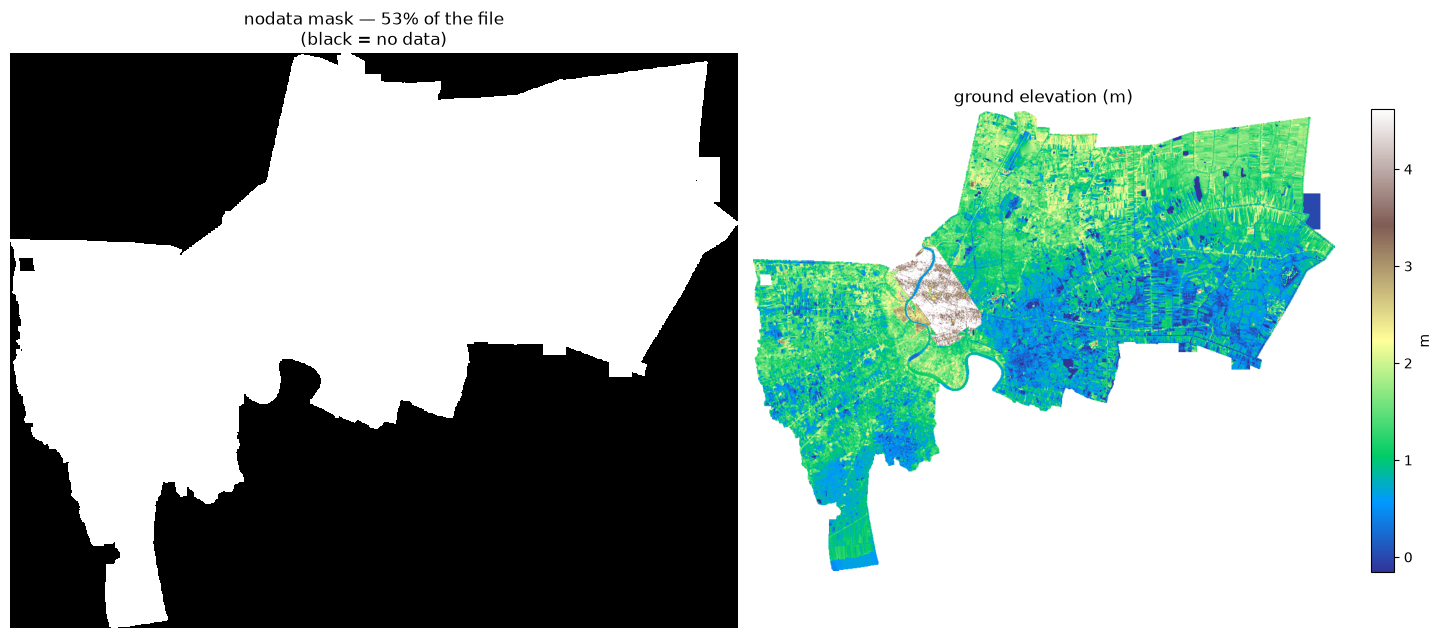

In [3]:
src = rasterio.open(T.dtm_path())
ov = 64
coarse = src.read(1, out_shape=(src.height // ov, src.width // ov)).astype("float32")
missing = (coarse == src.nodata) | ~np.isfinite(coarse)
elev = np.where(missing, np.nan, coarse)

fig, ax = plt.subplots(1, 2, figsize=(15, 6.5))
ax[0].imshow(missing, cmap="gray_r", interpolation="nearest")
ax[0].set_title(f"nodata mask — {100 * missing.mean():.0f}% of the file\n(black = no data)")
im = ax[1].imshow(elev, cmap="terrain",
                  vmin=np.nanpercentile(elev, 1), vmax=np.nanpercentile(elev, 99))
ax[1].set_title("ground elevation (m)")
plt.colorbar(im, ax=ax[1], shrink=0.75, label="m")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.savefig(REPORTS / "dtm_overview.png", dpi=110)
plt.show()

> **The nodata is the shape of Bangkok.** The valid-data footprint traces the
> BMA administrative boundary — this is a city survey stored in a rectangle, and
> everything outside the boundary is empty. It is **not** water.
>
> Two consequences:
>
> **Nodata must be treated as an open edge, never as ground.** `read_patch()`
> converts it to `NaN`, and `fill_depressions()` treats any cell next to it as
> an outlet, so a hollow at the city edge drains outward instead of filling to
> the height of the whole city. There is a test for this
> (`test_nodata_is_an_outlet_not_a_cliff`) because getting it wrong would be
> invisible in the output and catastrophic in the features.
>
> **`dist_to_water_km` cannot come from here.** The spec lists it as a terrain
> feature, and the obvious shortcut — "water is probably the nodata" — is simply
> false. See Part 5.
>
> Look at the elevation panel, though: the Chao Phraya is clearly visible as a
> dark meander, and the eastern districts show a fine rectangular grid of
> linear depressions. **Those are the canals.** We cannot measure distance to
> water today, but the canals are physically present in this raster, which is a
> genuine lead — see Part 5.

## 1.2 Is it bare earth, or does it include buildings?

In [4]:
# A bare-earth DTM of Bangkok should sit around 0-3 m nearly everywhere.
# Buildings would show up as a long upper tail and, more tellingly, as sharp
# metre-scale steps: high local roughness in the dense core and low roughness
# in the open east.
valid = elev[np.isfinite(elev)]
print("Elevation distribution over the whole city (m):")
for p in [0.1, 1, 5, 25, 50, 75, 95, 99, 99.9]:
    print(f"  p{p:<5} {np.percentile(valid, p):>7.2f}")
print(f"  min {valid.min():.2f}   max {valid.max():.2f}")

Elevation distribution over the whole city (m):
  p0.1     -3.77
  p1       -0.16
  p5        0.21
  p25       0.71
  p50       1.09
  p75       1.49
  p95       2.30
  p99       4.62
  p99.9     4.91
  min -16.74   max 8.95


In [5]:
# Local roughness at FULL resolution in two contrasting places: the dense inner
# city, and open land in the east. If rooftops were included, the inner-city
# window would be far rougher and much higher.
districts = T.districts()
def window_stats(name, size_m=1000):
    geom = districts.loc[districts.name == name, "geometry"].iloc[0]
    cx, cy = geom.centroid.x, geom.centroid.y
    half = size_m / 2
    patch = T.read_patch((cx - half, cy - half, cx + half, cy + half),
                         resolution_m=1.0, src=src)
    d = patch.dem
    dz = np.abs(np.diff(d, axis=1))
    return {
        "district": name,
        "valid_pct": round(100 * patch.valid_share, 1),
        "elev_p50": round(float(np.nanpercentile(d, 50)), 2),
        "elev_p99": round(float(np.nanpercentile(d, 99)), 2),
        "elev_max": round(float(np.nanmax(d)), 2),
        "median_step_cm": round(float(np.nanmedian(dz)) * 100, 1),
        "p99_step_cm": round(float(np.nanpercentile(dz, 99)) * 100, 1),
    }

pairs = ["Pathum Wan", "Bang Rak", "Nong Chok", "Lat Krabang"]
rough = pd.DataFrame([window_stats(n) for n in pairs])
rough.to_csv(REPORTS / "dtm_bare_earth_check.csv", index=False)
rough

,district,valid_pct,elev_p50,elev_p99,elev_max,median_step_cm,p99_step_cm
0,Pathum Wan,100.0,4.41,4.96,4.99,1.9,47.9
1,Bang Rak,100.0,4.68,4.97,4.99,1.3,71.3
2,Nong Chok,100.0,1.82,3.00,4.11,1.6,35.1
3,Lat Krabang,100.0,0.71,1.65,3.00,1.4,31.3


**How to read that table.** `median_step_cm` is the typical height change between
two neighbouring 1 m pixels, and `p99_step_cm` is the 99th-percentile jump.

- If this is genuine **bare earth**, the dense districts (Pathum Wan, Bang Rak)
  and the open ones (Nong Chok, Lat Krabang) will have similar, small steps —
  centimetres — and similar elevation ranges.
- If **buildings are included**, the dense districts will show metre-scale p99
  steps (building walls) and much higher `elev_max`, while the open districts
  stay flat.

Whatever the table says, record it here rather than assuming. If buildings turn
out to be present, depression depth in dense districts is measuring courtyards
and light wells rather than road hollows, and the feature must be described that
way — or the raster masked to road corridors once road centrelines arrive
(spec §D.5).

## 1.3 Does the DTM cover the districts we have sensors in?

In [6]:
alias = TCFG.get("district_name_aliases", {})
reg = pd.read_csv(CFG["paths"]["station_registry"], encoding="utf-8-sig")
flood_districts = sorted(reg.loc[reg.sensor_type == "flood", "district"].dropna().unique())
mapped = [alias.get(d, d) for d in flood_districts]

known = set(districts.name)
missing_names = [d for d, m in zip(flood_districts, mapped) if m not in known]
print(f"{len(flood_districts)} districts have flood sensors")
print(f"boundary file has {len(known)} districts")
print("unmatched after aliasing:", missing_names or "none")
assert not missing_names, "district name join would silently drop a district"
print()
print("Alias applied:", alias)

33 districts have flood sensors
boundary file has 50 districts
unmatched after aliasing: none

Alias applied: {'Watthana': 'Vadhana'}


> One district is romanised differently in the two files — the registry says
> *Watthana*, the boundary file says *Vadhana*. Both are correct
> transliterations of วัฒนา. Left unhandled, that district would silently vanish
> from every terrain feature and nobody would notice, because a `merge` that
> drops a row does not raise. The alias lives in `config.yaml`, and the assertion
> above turns a silent loss into a loud failure.

---
# Part 2 — Local features at 1 metre

The expensive part. For each of the 50 districts:

1. read the district plus a 500 m buffer, in overlapping tiles;
2. fill depressions in each tile — the standard sink-filling algorithm, which is
   "pour water over the terrain until nothing can drain any further";
3. **depression depth = filled − original**. Literally: how deep water would be
   here if this dip filled to its brim;
4. slope by Horn's method;
5. keep only each tile's core so nothing is double-counted, clip to the district
   polygon, and fold the values into running histograms.

The histograms are the trick that makes this affordable. Nong Chok is 236 km²
— 236 million pixels at 1 m, nearly a gigabyte before the three copies that sink
filling needs. Binning as we go keeps memory flat regardless of district size,
and 1 cm bins give percentiles accurate to a centimetre.

**The one approximation to keep in mind.** Tiles overlap by 256 m, so a dip
smaller than that is measured exactly. A basin larger than the overlap gets cut
and its depth underestimated. `depression_truncated_share` reports how often
depressions touched a tile edge, so the size of that approximation is measured
rather than assumed.

In [7]:
t0 = time.time()
rows = []
raster_dir = Path(TCFG["outputs"]["rasters_dir"])
if TCFG["outputs"]["write_rasters"]:
    raster_dir.mkdir(parents=True, exist_ok=True)

for i, d in districts.iterrows():
    out_tif = (str(raster_dir / f"depression_{d['name'].replace(' ', '_')}.tif")
               if TCFG["outputs"]["write_rasters"] else None)
    # restrict_to_ground=False ON PURPOSE. config has ground_mask.enabled: true,
# so leaving this off would silently mask here too -- and Part 2b would be
# comparing masked against masked, which is no comparison at all.
# This loop is the BEFORE. Part 2b is the after.
    rows.append(T.district_terrain(d.geometry, d["name"], src=src,
                                   restrict_to_ground=False,
                                   write_raster_to=out_tif))

terr = pd.DataFrame(rows)
print()
print(f"{len(terr)} districts in {(time.time() - t0) / 60:.1f} minutes")

  Phra Nakhon                5.3 km2  coverage 100.0%  median elev  2.80 m  dips  30.1% of area
  Dusit                     11.3 km2  coverage 100.0%  median elev  4.48 m  dips  37.1% of area
  Nong Chok                237.4 km2  coverage 100.0%  median elev  1.25 m  dips  47.8% of area
  Bang Rak                   4.0 km2  coverage 100.0%  median elev  4.54 m  dips  33.3% of area
  Bang Khen                 41.0 km2  coverage 100.0%  median elev  1.52 m  dips  28.4% of area
  Bang Kapi                 27.2 km2  coverage 100.0%  median elev  0.63 m  dips  24.1% of area
  Pathum Wan                 8.0 km2  coverage 100.0%  median elev  4.56 m  dips  42.6% of area
  Pom Prap Sattru Phai       2.4 km2  coverage 100.0%  median elev  4.80 m  dips  28.1% of area
  Phra Khanong              13.3 km2  coverage 100.0%  median elev  0.41 m  dips  26.4% of area
  Min Buri                  60.4 km2  coverage 100.0%  median elev  0.91 m  dips  40.2% of area
  Lat Krabang              129.3 km2  co

In [8]:
terr["elev_range_m"] = terr["elev_m_p99"] - terr["elev_m_p1"]
terr = terr.sort_values("elev_m_p50").reset_index(drop=True)
terr["elev_rank_citywide"] = terr["elev_m_p50"].rank(method="min").astype(int)

cols = ["district", "area_km2", "dtm_coverage_pct", "elev_m_p50", "elev_m_p10",
        "elev_range_m", "depression_depth_m_p99", "depressed_area_share",
        "depression_truncated_share"]
print("Lowest-lying districts first")
display(terr[cols].head(12).round(3))
print()
print("Highest")
display(terr[cols].tail(6).round(3))

Lowest-lying districts first


,district,area_km2,dtm_coverage_pct,elev_m_p50,elev_m_p10,elev_range_m,depression_depth_m_p99,depressed_area_share,depression_truncated_share
0,Phra Khanong,13.259,100.00,0.415,-0.045,2.27,0.835,0.264,0.0
1,Suan Luang,24.428,100.00,0.515,0.025,2.05,0.705,0.224,0.0
2,Lat Krabang,129.286,99.96,0.625,-0.065,2.70,1.175,0.418,0.0
3,Vadhana,12.982,100.00,0.635,0.185,5.32,1.685,0.216,0.0
4,Bang Kapi,27.193,100.00,0.635,-0.065,2.67,1.055,0.241,0.0
5,Prawet,53.986,100.00,0.685,-0.115,3.45,1.445,0.304,0.0
6,Bang Na,19.083,99.98,0.735,0.185,2.47,1.025,0.279,0.0
7,Saphan Sung,27.982,100.00,0.835,-0.085,2.89,1.145,0.283,0.0
8,Bang Khun Thian,123.346,100.00,0.855,0.455,2.18,0.885,0.505,0.0
9,Thung Khru,31.902,100.00,0.875,0.305,2.08,0.875,0.393,0.0



Highest


,district,area_km2,dtm_coverage_pct,elev_m_p50,elev_m_p10,elev_range_m,depression_depth_m_p99,depressed_area_share,depression_truncated_share
44,Dusit,11.332,100.0,4.485,1.585,4.47,2.665,0.371,0.0
45,Bang Rak,4.048,100.0,4.545,1.185,4.20,2.815,0.333,0.0
46,Pathum Wan,8.046,100.0,4.565,2.175,4.34,2.605,0.426,0.0
47,Bang Phlat,12.147,100.0,4.575,1.535,4.47,2.515,0.313,0.0
48,Ratchathewi,7.210,100.0,4.685,2.865,3.81,2.875,0.386,0.0
49,Pom Prap Sattru Phai,2.413,100.0,4.805,2.925,2.67,1.855,0.281,0.0


In [9]:
print("How good was the tiling approximation?")
print(f"  median share of depressions touching a tile edge : "
      f"{terr.depression_truncated_share.median():.4f}")
print(f"  worst district                                   : "
      f"{terr.depression_truncated_share.max():.4f} "
      f"({terr.loc[terr.depression_truncated_share.idxmax(), 'district']})")
print()
print("Anything above a few percent means large basins are being cut by tiling;")
print("raise terrain.local.tile_overlap_px and re-run that district if so.")

How good was the tiling approximation?
  median share of depressions touching a tile edge : 0.0000
  worst district                                   : 0.0000 (Phra Khanong)

Anything above a few percent means large basins are being cut by tiling;
raise terrain.local.tile_overlap_px and re-run that district if so.


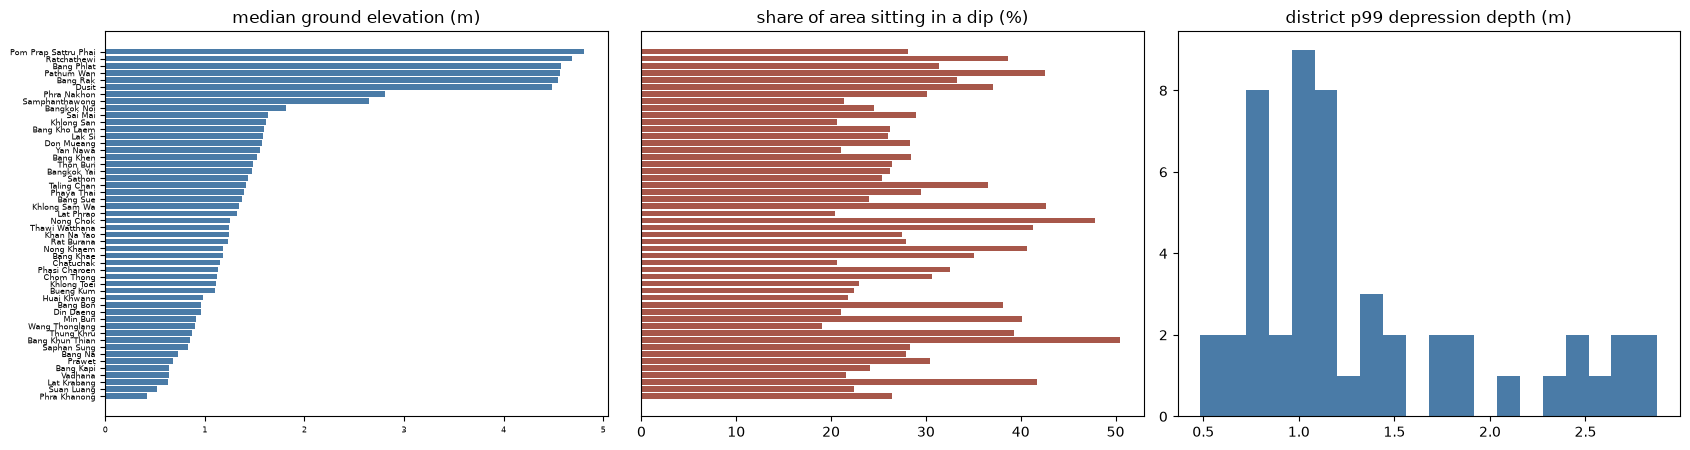

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
ax[0].barh(terr.district, terr.elev_m_p50, color="#4a7ba7")
ax[0].set_title("median ground elevation (m)"); ax[0].tick_params(labelsize=6)
ax[1].barh(terr.district, 100 * terr.depressed_area_share, color="#a7574a")
ax[1].set_title("share of area sitting in a dip (%)"); ax[1].set_yticks([])
ax[2].hist(terr.depression_depth_m_p99, bins=20, color="#4a7ba7")
ax[2].set_title("district p99 depression depth (m)")
plt.tight_layout()
plt.savefig(REPORTS / "district_terrain.png", dpi=110)
plt.show()

---
# Part 2b — Phase 1.5: recovering the ground surface

**Part 2 above is contaminated, and this section is the fix.**

The medians it reports are impossible: Pathum Wan 4.57 m, Bang Rak 4.55 m, against
0.63 m in open Lat Krabang. Bangkok's inner districts are not four metres higher
than its outskirts. `DTM_1M` is not bare earth in dense areas — buildings were
stripped from a surface model and the holes interpolated, so over a large
footprint the fill drifts up toward roof height.

The tell is in Part 2's own output: **the highest districts have the deepest
depressions** (Pathum Wan p95 = 1.89 m against Phra Khanong 0.45 m). In a flat
delta city that is backwards. Those are not road dips — they are streets measured
against rooftops.

**The contamination is one-sided, which is what makes it fixable.** Interpolated
buildings sit *above* the real surface, never below. Streets, canals and open
ground form the low surface and run in a connected network through every
district. Taking a rolling minimum over a window wider than a city block, then
keeping cells close to it, selects the surface water actually runs on.

**Two masks, applied together — not one or the other.** Measured on Bang Rak:

| Mask | elevation p50 | area kept |
|---|---|---|
| none | 4.54 m | 100% |
| roads only, 3 m buffer | 3.77 m | 0.6% |
| roads only, 15 m buffer | 4.31 m | 1.5% |
| ground only | 1.72 m | 9.4% |
| **roads AND ground** | **1.56 m** | 0.9% |

Roads alone barely help, which was a surprise. The interpolated fill does not
stop at the building outline — it bleeds across narrow streets, so even a 3 m
buffer around a centreline lands on the shoulder of a dome.

Roads still matter: they guarantee the surviving cells are on a *road* rather
than in a canal or a car park, which is what the supervisor's formula needs and
what the ground mask alone cannot tell apart. Run
`python scripts/fetch_osm_roads.py` to add them; the notebook works without.

Measured on real districts (`restrict_to_ground=True`):

| District | | elevation p50 | depression p95 |
|---|---|---|---|
| Bang Rak | dense | 4.54 → **1.25 m** | 1.83 → **0.18 m** |
| Phra Khanong | open, control | 0.41 → **0.34 m** | 0.45 → **0.15 m** |

That is the signature of a correct fix: a large change where the problem was, a
small one where it was not. And note what happens to the feature itself —
depression depth goes from 1.83 vs 0.45 (meaning different things in different
places) to 0.18 vs 0.15 (measuring one thing everywhere). That is the difference
between a feature a model can use and one it cannot.

**It is still an estimate of the low surface, not a true bare-earth model.** The
real answer is one email: *what is `DTM_1M` — bare earth or surface, what
filtering produced it, what vertical datum?* That belongs on the BMA data
request.

In [11]:
# Choose the mask. Roads if we have them, inferred ground otherwise.
from pathlib import Path
roads = None
roads_path = Path(CFG["paths"]["gis"]) / "osm_roads.gpkg"
if roads_path.exists():
    import geopandas as gpd
    roads = gpd.read_file(roads_path).to_crs(TCFG["working_crs"])
    roads = roads[~roads.bridge & ~roads.tunnel]      # a viaduct is not the ground
    print(f"road mask: {len(roads):,} OSM segments (bridges and tunnels dropped)")
else:
    print("no OSM roads found -> using the inferred ground mask")
    print("  (run `python scripts/fetch_osm_roads.py` for the better method)")
print("ground_mask settings:", TCFG["ground_mask"])

road mask: 213,332 OSM segments (bridges and tunnels dropped)
ground_mask settings: {'enabled': True, 'window_m': 100, 'tolerance_m': 1.0, 'min_ground_share': 0.01}


In [12]:
# Recompute the local features on the ground surface only.
t0 = time.time()
rows_g = []
for i, d in districts.iterrows():
    rows_g.append(T.district_terrain(d.geometry, d["name"], src=src,
                                     restrict_to_ground=True, roads=roads,
                                     verbose=True))
terr_ground = pd.DataFrame(rows_g)
print()
print(f"{len(terr_ground)} districts in {(time.time() - t0) / 60:.1f} minutes")

suspect = terr_ground[terr_ground.mask_suspect]
if len(suspect):
    print(f"\nWARNING: {len(suspect)} districts kept under "
          f"{100 * TCFG['ground_mask']['min_ground_share']:.0f}% of their area -- "
          "the mask may have collapsed onto canal beds:")
    display(suspect[["district", "ground_share", "elev_m_p50"]])

  Phra Nakhon                5.3 km2  coverage  10.6%  median elev  2.45 m  dips   1.7% of area
  Dusit                     11.3 km2  coverage   2.5%  median elev  2.01 m  dips  15.3% of area
  Nong Chok                237.4 km2  coverage   3.4%  median elev  1.30 m  dips   2.3% of area
  Bang Rak                   4.0 km2  coverage   4.6%  median elev  1.41 m  dips   7.6% of area
  Bang Khen                 41.0 km2  coverage  14.4%  median elev  1.57 m  dips   2.2% of area
  Bang Kapi                 27.2 km2  coverage  18.0%  median elev  0.52 m  dips   2.9% of area
  Pathum Wan                 8.0 km2  coverage   3.2%  median elev  2.56 m  dips  10.1% of area
  Pom Prap Sattru Phai       2.4 km2  coverage   5.5%  median elev  2.85 m  dips   6.5% of area
  Phra Khanong              13.3 km2  coverage  20.3%  median elev  0.28 m  dips   2.8% of area
  Min Buri                  60.4 km2  coverage   8.3%  median elev  1.05 m  dips   2.3% of area
  Lat Krabang              129.3 km2  co

In [13]:
# Before and after, side by side. This is the evidence, not the assertion.
cmp = (terr[["district", "elev_m_p50", "depression_depth_m_p95", "depressed_area_share"]]
       .merge(terr_ground[["district", "elev_m_p50", "depression_depth_m_p95",
                           "depressed_area_share", "ground_share", "mask"]],
              on="district", suffixes=("_raw", "_ground")))
cmp["elev_drop_m"] = (cmp.elev_m_p50_raw - cmp.elev_m_p50_ground).round(2)
cmp = cmp.sort_values("elev_drop_m", ascending=False)
cmp.to_csv(REPORTS / "ground_mask_before_after.csv", index=False)

print("Districts where the raster was most contaminated (largest correction):")
display(cmp.head(10).round(2))
print()
print("Districts that barely moved -- these were already bare earth:")
display(cmp.tail(5).round(2))
print()
print(f"median correction across the city: {cmp.elev_drop_m.median():.2f} m")
print(f"depression p95, before: {cmp.depression_depth_m_p95_raw.median():.2f} m"
      f"   after: {cmp.depression_depth_m_p95_ground.median():.2f} m")

terr_ground.to_parquet(Path(TCFG["outputs"]["district_stats"]).with_name(
    "terrain_district_ground.parquet"), index=False)

Districts where the raster was most contaminated (largest correction):


,district,elev_m_p50_raw,depression_depth_m_p95_raw,depressed_area_share_raw,elev_m_p50_ground,depression_depth_m_p95_ground,depressed_area_share_ground,ground_share,mask,elev_drop_m
45,Bang Rak,4.54,1.84,0.33,1.41,0.10,0.08,0.05,ground+roads,3.13
47,Bang Phlat,4.57,1.69,0.31,1.93,0.08,0.07,0.05,ground+roads,2.64
44,Dusit,4.48,1.88,0.37,2.01,0.18,0.15,0.02,ground+roads,2.47
48,Ratchathewi,4.68,1.88,0.39,2.36,0.16,0.13,0.02,ground+roads,2.32
46,Pathum Wan,4.56,1.88,0.43,2.56,0.14,0.10,0.03,ground+roads,2.00
49,Pom Prap Sattru Phai,4.80,1.10,0.28,2.85,0.08,0.06,0.05,ground+roads,1.95
29,Phaya Thai,1.39,1.70,0.29,0.83,0.00,0.04,0.12,ground+roads,0.56
43,Phra Nakhon,2.80,0.80,0.30,2.45,0.00,0.02,0.11,ground+roads,0.35
3,Vadhana,0.63,0.44,0.22,0.42,0.00,0.03,0.16,ground+roads,0.21
12,Din Daeng,0.96,0.58,0.21,0.77,0.00,0.03,0.21,ground+roads,0.19



Districts that barely moved -- these were already bare earth:


,district,elev_m_p50_raw,depression_depth_m_p95_raw,depressed_area_share_raw,elev_m_p50_ground,depression_depth_m_p95_ground,depressed_area_share_ground,ground_share,mask,elev_drop_m
36,Don Mueang,1.57,0.70,0.28,1.69,0.00,0.02,0.13,ground+roads,-0.12
2,Lat Krabang,0.62,0.68,0.42,0.74,0.00,0.03,0.06,ground+roads,-0.12
11,Min Buri,0.91,0.80,0.40,1.05,0.00,0.02,0.08,ground+roads,-0.14
8,Bang Khun Thian,0.85,0.52,0.50,1.00,0.08,0.09,0.10,ground,-0.15
27,Khlong Sam Wa,1.34,0.80,0.43,1.56,0.00,0.02,0.06,ground+roads,-0.22



median correction across the city: 0.07 m
depression p95, before: 0.62 m   after: 0.01 m


---
# Part 3 — Routing features, whole city, 10 metres

Flow accumulation is **not** a local property: how much land drains through a
cell depends on the entire catchment above it, and catchments cross district
lines. So this runs over the whole city in one pass, at 10 m, which keeps about
16 million cells — small enough for the sparse flow matrix to fit comfortably.

### Why routing needs one extra step

Sink filling makes every depression perfectly flat. A perfectly flat area has no
steepest-descent direction, so D8 routing stalls: every flat cell becomes its
own outlet and flow accumulation comes out **low** inside depressions. That is
backwards — dips are where water collects, and finding dips is the entire point
of this notebook.

`routing_surface()` puts a sub-millimetre bowl shape back (`filled − 0.001 ×
depth`), which is far too small to distort any real gradient but enough to give
every cell in a hollow a direction to send water: inward, toward the low point.

The first version of this module did not do that, and reported lower wetness
inside a 40 cm bowl than on the plane around it.
`tests/test_terrain.py::test_twi_higher_in_dip` exists so it cannot come back.

In [14]:
res = TCFG["routing"]["resolution_m"]
bounds = src.bounds
t0 = time.time()
city = T.read_patch((bounds.left, bounds.bottom, bounds.right, bounds.top),
                    resolution_m=res, src=src)
print(f"city at {res} m: {city.dem.shape}, {city.valid.sum():,} valid cells "
      f"({100 * city.valid_share:.0f}%), read in {time.time() - t0:.0f}s")

city at 10.0 m: (5232, 6622), 16,168,834 valid cells (47%), read in 0s


In [15]:
t0 = time.time()
filled_city = T.fill_depressions(city.dem)
surface = T.routing_surface(city.dem, filled_city)
slope_city = T.slope_degrees(surface, city.cellsize_m)
print(f"filled and prepared in {time.time() - t0:.0f}s")

t0 = time.time()
acc, flow_report = T.flow_accumulation(surface, city.cellsize_m)
print(f"flow accumulation in {(time.time() - t0) / 60:.1f} min")
for k, v in flow_report.items():
    print(f"  {k:<24}: {v}")
assert flow_report["converged"], (
    "Flow accumulation hit the iteration cap, so long flow paths are "
    "underestimated. Raise terrain.routing.max_iterations and re-run."
)

filled and prepared in 9s
    flow accumulation: iteration 100, max change 79
    flow accumulation: iteration 200, max change 37
flow accumulation in 0.6 min
  iterations              : 222
  converged               : True
  cells                   : 16168834
  max_accumulation_cells  : 11204.0
  cellsize_m              : 10.0


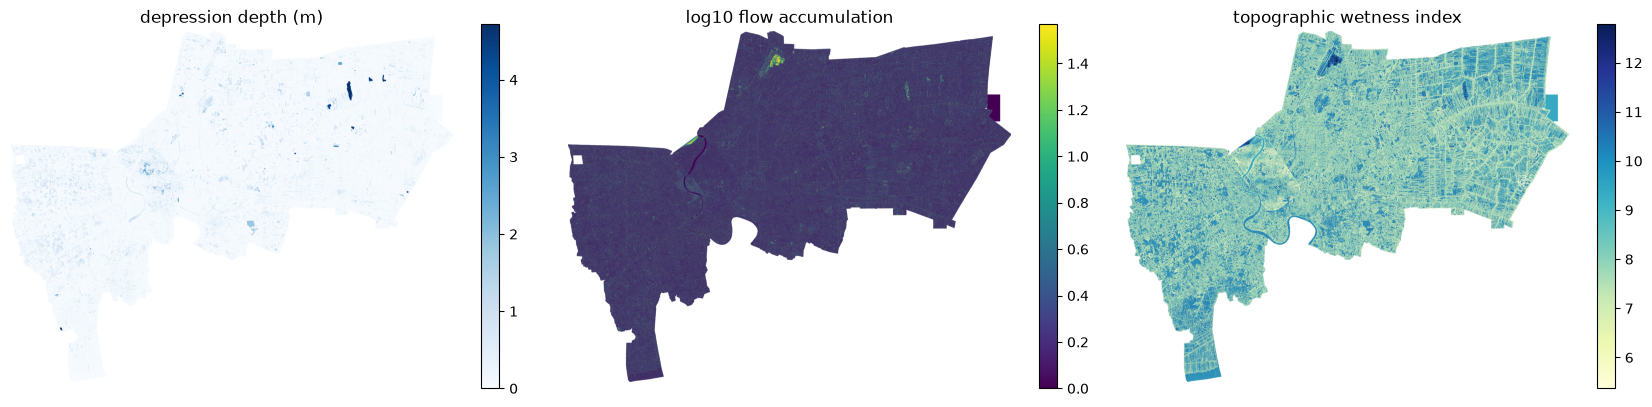

In [16]:
twi = T.topographic_wetness_index(acc, slope_city, city.cellsize_m)
depth_city = T.depression_depth(city.dem, filled_city)

fig, ax = plt.subplots(1, 3, figsize=(17, 5.5))
for a, (arr, title, cmap, pl, ph) in zip(ax, [
    (depth_city, "depression depth (m)", "Blues", 50, 99.9),
    (np.log10(np.maximum(acc, 1)), "log10 flow accumulation", "viridis", 1, 99),
    (twi, "topographic wetness index", "YlGnBu", 1, 99),
]):
    im = a.imshow(arr, cmap=cmap, vmin=np.nanpercentile(arr, pl),
                  vmax=np.nanpercentile(arr, ph))
    a.set_title(title); a.axis("off")
    plt.colorbar(im, ax=a, shrink=0.7)
plt.tight_layout()
plt.savefig(REPORTS / "routing_features.png", dpi=110)
plt.show()

In [17]:
# Summarise the routing grids per district and join onto the local table.
from rasterio.features import geometry_mask

routing_rows = []
for _, d in districts.iterrows():
    inside = ~geometry_mask([d.geometry], out_shape=city.dem.shape,
                            transform=city.transform, invert=False)
    m = inside & city.valid
    if not m.any():
        continue
    rec = {"district": d["name"]}
    rec.update(T.summarise(np.where(m, twi, np.nan), "twi"))
    rec.update(T.summarise(np.where(m, np.log10(np.maximum(acc, 1)), np.nan),
                           "log_flow_acc"))
    routing_rows.append(rec)

routing = pd.DataFrame(routing_rows)
terr = terr.merge(routing, on="district", how="left")
print(f"{len(routing)} districts summarised; terrain table now has {terr.shape[1]} columns")
terr[["district", "twi_mean", "twi_p95", "log_flow_acc_p95"]].head()

50 districts summarised; terrain table now has 76 columns


,district,twi_mean,twi_p95,log_flow_acc_p95
0,Phra Khanong,8.783344,11.831450,1.176091
1,Suan Luang,8.423236,11.649129,1.204120
2,Lat Krabang,8.295403,11.543769,1.204120
3,Vadhana,8.192451,11.543769,1.204120
4,Bang Kapi,8.341129,11.649129,1.204120


In [18]:
out = Path(TCFG["outputs"]["district_stats"])
out.parent.mkdir(parents=True, exist_ok=True)
terr.to_parquet(out, index=False)
terr.to_csv(REPORTS / "terrain_district.csv", index=False)
print("wrote", out, "-", terr.shape)

wrote data/features/terrain_district.parquet - (50, 76)


---
# Part 4 — The retest: does terrain relate to flooding at all?

This is what Phase 1 exists to answer, and it has to be set up honestly, because
the honest version is much weaker than it sounds.

**What we can compare.** Phase 0 produced 837 flood events at the 15 cm tier,
each tagged with a station. The station registry gives each station a district —
and the *district* assignment is trustworthy even though the *coordinates* are
not, because it comes from the station code prefix rather than from a guessed
position. So we can ask: do districts with deeper dips flood more often?

**Why this is a weak test, stated up front:**

- **n = 33.** Only 33 districts have flood sensors. With 33 points, a
  correlation needs to be around 0.34 before it is even nominally significant,
  and we are looking at several terrain variables, so some will pass by chance.
- **Wrong granularity.** Terrain acts over metres; a district is 10–200 km². We
  are averaging away exactly the variation that matters and then testing what
  is left.
- **Sensor placement is not random.** BMA installs flood sensors where flooding
  is known to happen. So a district's event count partly measures where sensors
  were put, not where water goes. Normalising by sensors per district helps and
  does not fix it.

A positive result here is encouraging but not conclusive. **A null result proves
nothing at all** — it is exactly what you would expect from testing a
metre-scale process at district scale. The real test needs station coordinates,
and Part 5 explains what that unlocks.

In [19]:
events = pd.read_csv(Path(CFG["paths"]["reports"]) / "phase0" / "flood_events.csv")
events = events[events.tier_cm == CFG["flood_event"]["primary_tier_cm"]]

st = reg.loc[reg.sensor_type == "flood", ["station_code", "district"]].dropna()
st["district"] = st["district"].map(lambda d: alias.get(d, d))

ev = events.merge(st, on="station_code", how="left")
unmatched = ev.district.isna().sum()
print(f"{len(ev)} events, {unmatched} could not be matched to a district")

per_district = (ev.groupby("district")
                  .agg(events=("station_code", "size"),
                       stations_with_events=("station_code", "nunique"),
                       total_minutes=("duration_minutes", "sum"),
                       deepest_cm=("peak_depth_cm", "max"))
                  .reset_index())
sensors = st.groupby("district").size().rename("sensors").reset_index()
per_district = sensors.merge(per_district, on="district", how="left").fillna(
    {"events": 0, "stations_with_events": 0, "total_minutes": 0})
per_district["events_per_sensor"] = per_district.events / per_district.sensors
per_district.to_csv(REPORTS / "flooding_by_district.csv", index=False)
per_district.sort_values("events_per_sensor", ascending=False).head(10)

837 events, 0 could not be matched to a district


,district,sensors,events,stations_with_events,total_minutes,deepest_cm,events_per_sensor
27,Sai Mai,1,48.0,1.0,2610.0,51.5,48.000000
10,Bueng Kum,2,38.0,2.0,3455.0,39.4,19.000000
25,Prawet,2,38.0,1.0,6335.0,43.2,19.000000
30,Suan Luang,3,46.0,3.0,4890.0,40.3,15.333333
29,Sathon,4,61.0,4.0,5015.0,45.4,15.250000
13,Din Daeng,8,107.0,7.0,7975.0,48.9,13.375000
11,Chatuchak,7,84.0,7.0,11435.0,148.8,12.000000
15,Huai Khwang,1,12.0,1.0,1035.0,36.0,12.000000
0,Bang Bon,2,23.0,2.0,920.0,29.5,11.500000
6,Bang Na,5,47.0,5.0,5090.0,50.9,9.400000


In [20]:
joined = per_district.merge(terr, on="district", how="left")
print(f"{len(joined)} districts with both flood sensors and terrain")

candidates = [
    ("elev_m_p50", "median ground elevation"),
    ("elev_m_p10", "elevation of the low tenth"),
    ("elev_range_m", "relief within the district"),
    ("depression_depth_m_mean", "mean depression depth"),
    ("depression_depth_m_p95", "p95 depression depth"),
    ("depression_depth_m_p99", "p99 depression depth"),
    ("depressed_area_share", "share of area in a dip"),
    ("slope_deg_p50", "median slope"),
    ("twi_mean", "mean wetness index"),
    ("twi_p95", "p95 wetness index"),
    ("log_flow_acc_p95", "p95 log flow accumulation"),
]

from scipy.stats import pearsonr, spearmanr
res = []
for col, label in candidates:
    if col not in joined:
        continue
    sub = joined[[col, "events_per_sensor"]].dropna()
    if len(sub) < 10:
        continue
    r, pv = pearsonr(sub[col], sub.events_per_sensor)
    rs, ps = spearmanr(sub[col], sub.events_per_sensor)
    res.append({"feature": col, "meaning": label, "n": len(sub),
                "pearson_r": round(r, 3), "pearson_p": round(pv, 4),
                "spearman_r": round(rs, 3), "spearman_p": round(ps, 4)})
corr = pd.DataFrame(res).sort_values("spearman_r", key=abs, ascending=False)
corr.to_csv(REPORTS / "terrain_vs_flooding.csv", index=False)
corr

33 districts with both flood sensors and terrain


,feature,meaning,n,pearson_r,pearson_p,spearman_r,spearman_p
8,twi_mean,mean wetness index,33,-0.164,0.3619,-0.231,0.1963
1,elev_m_p10,elevation of the low tenth,33,-0.163,0.3649,-0.215,0.2288
7,slope_deg_p50,median slope,33,0.219,0.2202,0.213,0.2343
6,depressed_area_share,share of area in a dip,33,-0.154,0.3919,-0.210,0.2414
0,elev_m_p50,median ground elevation,33,-0.176,0.3273,-0.169,0.3466
9,twi_p95,p95 wetness index,33,-0.073,0.6877,-0.160,0.3751
5,depression_depth_m_p99,p99 depression depth,33,-0.007,0.9704,0.153,0.3945
10,log_flow_acc_p95,p95 log flow accumulation,33,0.238,0.1825,0.118,0.5118
4,depression_depth_m_p95,p95 depression depth,33,-0.035,0.8488,0.083,0.6479
2,elev_range_m,relief within the district,33,-0.057,0.7517,0.068,0.7069


In [21]:
# The comparison that motivated this whole phase: 1 m vs the 31 m SRTM.
# Earlier versions reported every terrain correlation below 0.08. If the 1 m
# numbers above are not clearly larger, terrain really is weak at district
# scale — which is a legitimate finding, and different from "we tested it wrong".
best = corr.spearman_r.abs().max() if len(corr) else float("nan")
print(f"strongest |Spearman| at 1 m, district scale : {best:.3f}")
print(f"reported previously with the 31 m SRTM      : below 0.080")
print()
if best > 0.30:
    print("-> Terrain carries real signal at district scale. Worth taking into")
    print("   Phase 3 as a feature, and a strong argument for station coordinates.")
elif best > 0.15:
    print("-> Weak but non-trivial signal. Keep the features; expect them to")
    print("   matter more once they can be sampled at the sensor rather than")
    print("   averaged over 20 square kilometres.")
else:
    print("-> No usable signal at DISTRICT scale. Note carefully what this does")
    print("   and does not show: it does not mean terrain is uninformative, it")
    print("   means a 20 km2 average of a metre-scale process is uninformative.")
    print("   Report it that way. The test that matters needs coordinates.")

strongest |Spearman| at 1 m, district scale : 0.231
reported previously with the 31 m SRTM      : below 0.080

-> Weak but non-trivial signal. Keep the features; expect them to
   matter more once they can be sampled at the sensor rather than
   averaged over 20 square kilometres.


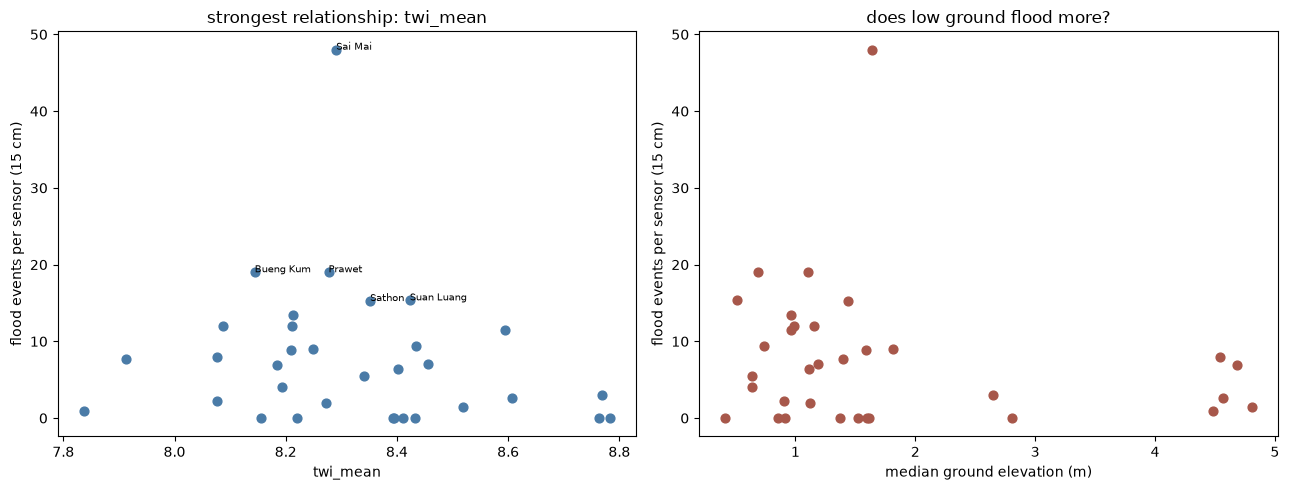

In [22]:
top = corr.iloc[0]["feature"] if len(corr) else "depression_depth_m_p99"
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(joined[top], joined.events_per_sensor, s=40, color="#4a7ba7")
for _, r in joined.iterrows():
    if r.events_per_sensor > joined.events_per_sensor.quantile(0.85):
        ax[0].annotate(r.district, (r[top], r.events_per_sensor), fontsize=7)
ax[0].set_xlabel(top); ax[0].set_ylabel("flood events per sensor (15 cm)")
ax[0].set_title(f"strongest relationship: {top}")

ax[1].scatter(joined.elev_m_p50, joined.events_per_sensor, s=40, color="#a7574a")
ax[1].set_xlabel("median ground elevation (m)")
ax[1].set_ylabel("flood events per sensor (15 cm)")
ax[1].set_title("does low ground flood more?")
plt.tight_layout()
plt.savefig(REPORTS / "terrain_vs_flooding.png", dpi=110)
plt.show()

---
# Part 5 — What Phase 1 cannot deliver, and exactly what would unblock it

Two features in the spec's terrain list are **not** produced here. Both are
blocked on data rather than on effort, and saying so plainly is more useful than
shipping a plausible-looking column that is quietly meaningless.

## 5.1 Per-station terrain — blocked on coordinates

The spec lists `elev_m`, `slope_deg`, `depression_depth_m`, `elev_rank_local`
and `dist_water_km` as **per-station** features. They are produced here per
*district* instead, and the reason is not a shortcut.

In [23]:
bbn = reg[(reg.sensor_type == "flood")
          & (reg.station_code.str.contains(".BBN.", regex=False))]
display(bbn[["station_code", "district", "lat", "lon", "confidence"]])
print("distinct coordinates among these sensors:",
      bbn[["lat", "lon"]].drop_duplicates().shape[0])
print()
print("Every flood sensor in Bang Bon carries the SAME point - the district")
print("centroid. Sampling a 1 m raster at that point would return one number,")
print("identical for every sensor in the district, describing whatever happens")
print("to sit at the centroid: possibly a rooftop, a canal, or a car park.")
print()
print("It would look like a per-station feature. It would be a fabrication.")

,station_code,district,lat,lon,confidence
0,FL.BBN.01,Bang Bon,13.646,100.37,High
1,FL.BBN.02,Bang Bon,13.646,100.37,High


distinct coordinates among these sensors: 1

Every flood sensor in Bang Bon carries the SAME point - the district
centroid. Sampling a 1 m raster at that point would return one number,
identical for every sensor in the district, describing whatever happens
to sit at the centroid: possibly a rooftop, a canal, or a car park.

It would look like a per-station feature. It would be a fabrication.


> `terrain.sample_points()` is written, tested and ready. It deliberately
> samples a *neighbourhood* (25 / 100 / 250 m radii) rather than a single pixel,
> because a lone 1 m pixel is noise and a sensor's position is known to a few
> metres at best.
>
> It refuses to run on `district_centroid` coordinates —
> `config.terrain.point_sampling.require_coord_quality` lists the qualities
> allowed through, and that is not one of them.
>
> **The day BMA sends the coordinate spreadsheet, Phase 1 becomes a re-run, not
> a rewrite.** That is the single highest-value item this notebook can point at:
> the 1 m terrain is already computed, city-wide, and waiting for somewhere to
> sample it.

## 5.2 `dist_to_water_km` — blocked on a canal layer

Distance to water needs a water layer, and we do not have one.

- The tempting shortcut — "the nodata is water" — is **false**. Part 1.1 showed
  the nodata is everything outside the BMA boundary.
- BMA's own canal network is spec §D.6 request #3, and would answer this
  directly along with far more valuable things (upstream routing, and eventually
  graph models).

**But there is a real lead.** Look again at the elevation panel in Part 1.1: the
Chao Phraya is unmistakable, and the eastern districts show a fine rectangular
grid of linear depressions — the canals are physically present in this raster.
A canal is a long, narrow, deep, consistent depression, which is a shape that
can be detected.

That is a genuine possibility for a later phase, and it is worth saying clearly
what it would and would not be: a canal network *derived* from terrain is an
approximation with no gate positions, no flow directions and no pump stations.
It would be worth building only if BMA cannot supply the real thing, and it
should never be presented as the real thing.

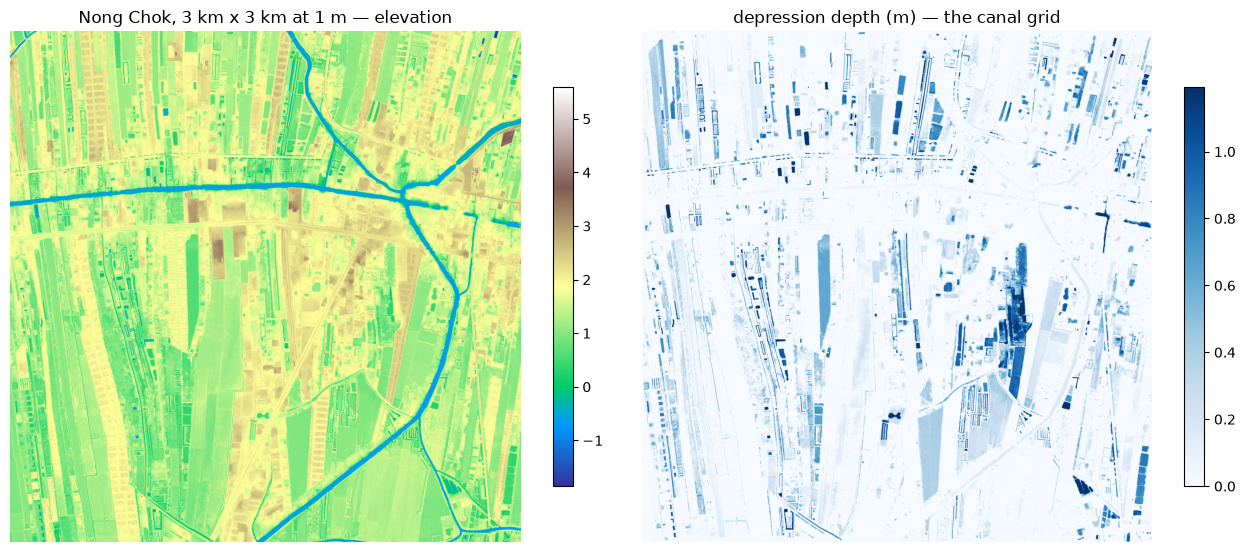

In [24]:
# Evidence for the lead: canals should show up as narrow, deep, linear dips.
# Nong Chok is the most agricultural district and has the clearest canal grid.
geom = districts.loc[districts.name == "Nong Chok", "geometry"].iloc[0]
cx, cy = geom.centroid.x, geom.centroid.y
patch = T.read_patch((cx - 1500, cy - 1500, cx + 1500, cy + 1500),
                     resolution_m=1.0, src=src)
d = T.depression_depth(patch.dem)

fig, ax = plt.subplots(1, 2, figsize=(13, 6))
im0 = ax[0].imshow(patch.dem, cmap="terrain")
ax[0].set_title("Nong Chok, 3 km x 3 km at 1 m — elevation")
plt.colorbar(im0, ax=ax[0], shrink=0.7)
im1 = ax[1].imshow(d, cmap="Blues", vmin=0, vmax=np.nanpercentile(d, 99.5))
ax[1].set_title("depression depth (m) — the canal grid")
plt.colorbar(im1, ax=ax[1], shrink=0.7)
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.savefig(REPORTS / "canals_visible_in_dtm.png", dpi=110)
plt.show()

## Part 6 — Summary

In [25]:
# Report the CORRECTED terrain, and say which mask produced it.
final = terr_ground.sort_values("elev_m_p50").reset_index(drop=True)
print("=" * 76)
print("PHASE 1 COMPLETE - TERRAIN FROM THE 1 m DTM")
print("=" * 76)
print("WHAT WAS PROCESSED")
print(f"  raster                  : {prof['gigapixels']} gigapixels at {prof['resolution_m']} m")
print(f"  districts               : {len(final)}")
print(f"  ground mask             : {final['mask'].mode()[0]} ({100 * final.ground_share.mean():.0f}% of area kept)")
print(f"  local features          : {TCFG['local']['resolution_m']} m, tiled")
print(f"  routing features        : {TCFG['routing']['resolution_m']} m, whole city, "
      f"{flow_report['cells']:,} cells")
print(f"  flow accumulation       : converged in {flow_report['iterations']} iterations")
print()
print("WHAT THE TERRAIN LOOKS LIKE")
print(f"  median ground elevation : {final.elev_m_p50.median():.2f} m")
print(f"  lowest district         : {final.iloc[0]['district']} ({final.iloc[0]['elev_m_p50']:.2f} m)")
print(f"  highest district        : {final.iloc[-1]['district']} ({final.iloc[-1]['elev_m_p50']:.2f} m)")
print(f"  total relief citywide   : about {final.elev_m_p99.max() - final.elev_m_p1.min():.1f} m")
print(f"  area sitting in a dip   : {100 * final.depressed_area_share.mean():.1f}% on average")
print()
print("THE RETEST")
print(f"  strongest |Spearman| vs flooding, district scale : {best:.3f}")
print(f"  previously, with the 31 m SRTM                   : below 0.080")
print()
print("STILL BLOCKED")
print("  per-station terrain  -> needs real sensor coordinates (BMA request #2)")
print("                          sample_points() is written and tested; the day")
print("                          the spreadsheet arrives this is a re-run.")
print("  dist_to_water_km     -> needs a canal layer (BMA request #3)")
print("=" * 76)
print()
print("Next: Phase 2 is already built - run notebooks/04_external_data.ipynb.")
src.close()

PHASE 1 COMPLETE - TERRAIN FROM THE 1 m DTM
WHAT WAS PROCESSED
  raster                  : 3.47 gigapixels at 1.0 m
  districts               : 50
  ground mask             : ground+roads (13% of area kept)
  local features          : 1.0 m, tiled
  routing features        : 10.0 m, whole city, 16,168,834 cells
  flow accumulation       : converged in 222 iterations

WHAT THE TERRAIN LOOKS LIKE
  median ground elevation : 1.25 m
  lowest district         : Phra Khanong (0.28 m)
  highest district        : Pom Prap Sattru Phai (2.85 m)
  total relief citywide   : about 5.9 m
  area sitting in a dip   : 3.4% on average

THE RETEST
  strongest |Spearman| vs flooding, district scale : 0.231
  previously, with the 31 m SRTM                   : below 0.080

STILL BLOCKED
  per-station terrain  -> needs real sensor coordinates (BMA request #2)
                          sample_points() is written and tested; the day
                          the spreadsheet arrives this is a re-run.
  dist_to_